In [53]:
import seaborn as sns

In [62]:
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
df = pd.read_csv('team_stats.csv')
df.head()

,Season,MatchDate,HomeTeam,AwayTeam,FullTimeHomeGoals,FullTimeAwayGoals,FullTimeResult,HalfTimeHomeGoals,HalfTimeAwayGoals,HalfTimeResult,...,HomeShotsOnTarget,AwayShotsOnTarget,HomeCorners,AwayCorners,HomeFouls,AwayFouls,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2023/24,2024-01-01,Liverpool,Newcastle,4,2,H,0,0,D,...,15,3,7,3,16,15,3,5,0,0
1,2023/24,2024-01-02,West Ham,Brighton,0,0,D,0,0,D,...,2,8,2,0,4,6,1,0,0,0
2,2023/24,2024-01-12,Burnley,Luton,1,1,D,1,0,H,...,7,5,2,8,7,12,1,0,0,0
3,2023/24,2024-01-13,Chelsea,Fulham,1,0,H,1,0,H,...,3,4,6,4,13,9,5,1,0,0
4,2023/24,2024-01-13,Newcastle,Man City,2,3,A,2,1,H,...,5,11,3,13,7,7,1,2,0,0


1. Tổng số điểm của mỗi đội trong mùa giải
Mục đích: Xác định đội mạnh nhất (thay vì chỉ nhìn bàn thắng) (biểu đồ cột)


In [56]:
home = df[['Season','HomeTeam','FullTimeResult']].copy()
home.columns = ['season','team','result']
home['points'] = home['result'].map({'H': 3, 'D' : 1, 'A': 0})

In [60]:
away = df[['Season','AwayTeam','FullTimeResult']].copy()
away.columns = ['season','team','result']
away['points'] = home['result'].map({'H':0, 'D':1, 'A':3})

tonghop = pd.concat([home,away],ignore_index=True)
tonghop2 = tonghop.groupby(['season','team'])[['points']].sum().reset_index().sort_values('points',ascending=False)
tonghop2.head()


,season,team,points
31,2024/25,Liverpool,82
20,2024/25,Arsenal,67
32,2024/25,Man City,64
34,2024/25,Newcastle,63
25,2024/25,Chelsea,63


In [98]:
tonghop2['team'].value_counts(normalize=True)

team
Liverpool           0.050
Brentford           0.050
West Ham            0.050
Tottenham           0.050
Man United          0.050
Everton             0.050
Wolves              0.050
Arsenal             0.050
Fulham              0.050
Crystal Palace      0.050
Brighton            0.050
Bournemouth         0.050
Aston Villa         0.050
Nott'm Forest       0.050
Chelsea             0.050
Newcastle           0.050
Man City            0.050
Ipswich             0.025
Leicester           0.025
Burnley             0.025
Southampton         0.025
Luton               0.025
Sheffield United    0.025
Name: proportion, dtype: float64

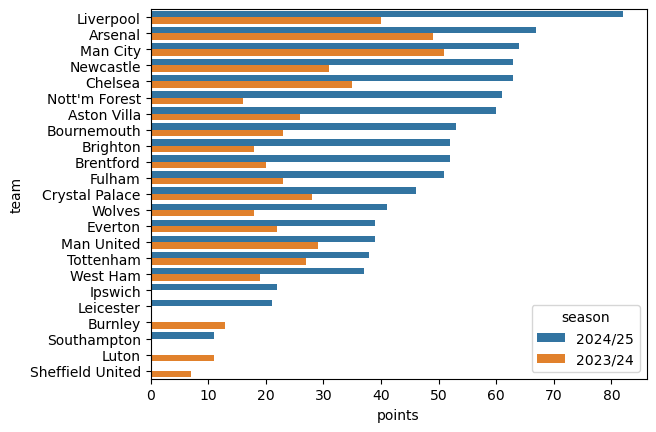

In [ ]:
sns.barplot(data=tonghop2, x='points',y='team',hue='season')
plt.show()

2. Hiệu suất sút trúng đích của đội chủ nhà và đội khách
Mục đích: Đánh giá hiệu quả dứt điểm.

In [73]:
hieusuat = df.groupby('Season', as_index=False)[['HomeShotsOnTarget','HomeShots','AwayShotsOnTarget','AwayShots']].sum()
hieusuat.columns = ['season','home','totalhome','away','totalaway']
hieusuat['hieusuatnha'] = hieusuat['home']/hieusuat['totalhome']
hieusuat['hieusuatkhach'] = hieusuat['away']/hieusuat['totalaway']
hieusuat2 = hieusuat[['season','hieusuatnha','hieusuatkhach']]
hieusuat2.head()

,season,hieusuatnha,hieusuatkhach
0,2023/24,0.356396,0.375326
1,2024/25,0.351452,0.349788


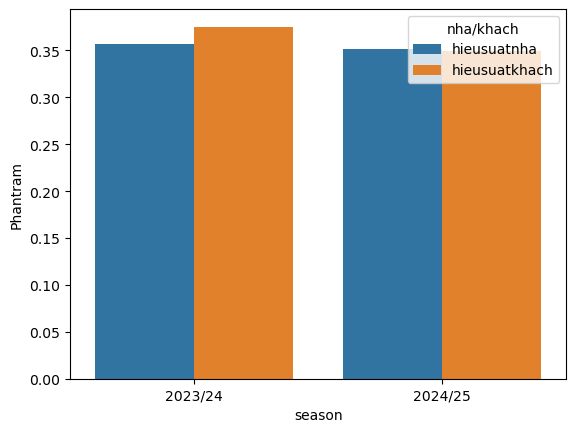

In [70]:
hs_melt = hieusuat2.melt(id_vars='season', var_name='nha/khach', value_name='Phantram')

sns.barplot(hs_melt, x='season', y='Phantram', hue='nha/khach')
plt.show()

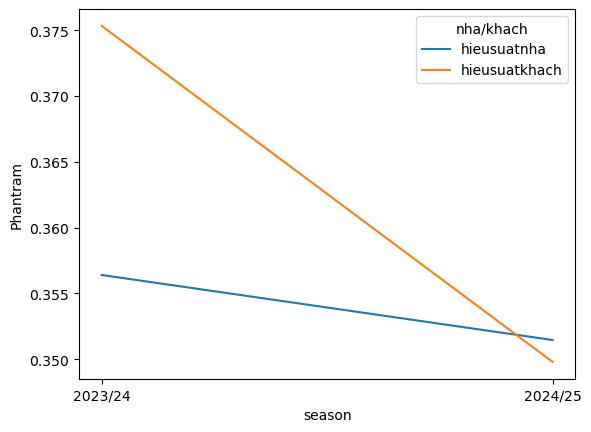

In [72]:
sns.lineplot(hs_melt, x='season', y='Phantram', hue='nha/khach')
plt.show()

3. Trung bình số thẻ vàng và đỏ mỗi đội
Mục đích: Đánh giá tính kỷ luật của đội.


In [94]:
tongso = pd.concat([
    df[['HomeTeam','HomeRedCards','HomeYellowCards']].rename(columns={'HomeTeam':'team','HomeRedCards':'red','HomeYellowCards':'yellow'}),
    df[['AwayTeam','AwayRedCards','AwayYellowCards']].rename(columns={'AwayTeam':'team','AwayRedCards':'red','AwayYellowCards':'yellow'})
]).groupby('team')[['red','yellow']].mean()
tongso1 = tongso.sort_values('yellow',ascending=False).reset_index()
tongso1.count()

team      23
red       23
yellow    23
dtype: int64

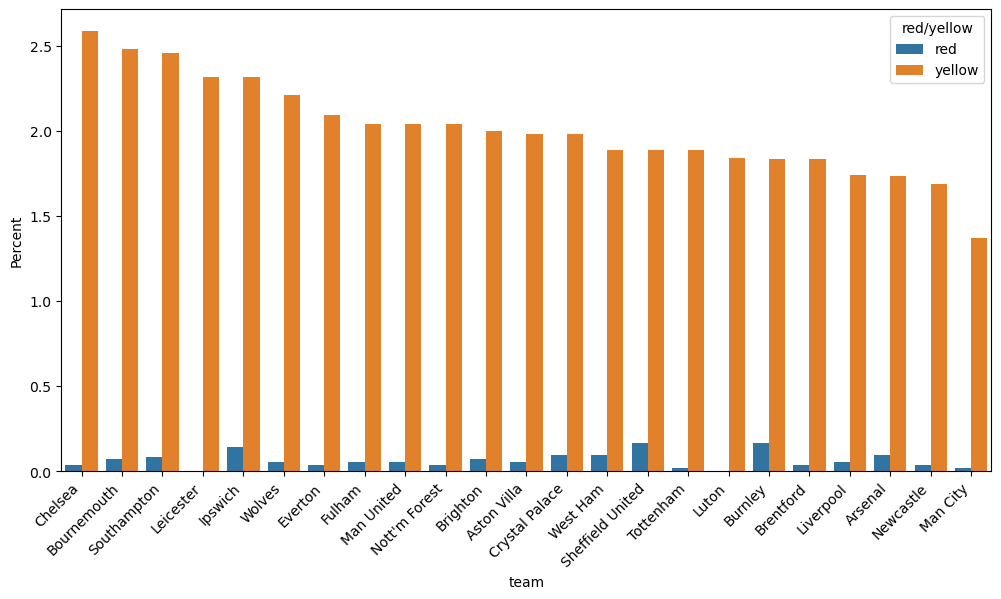

In [103]:
ts_melt = tongso1.melt(id_vars='team', var_name='red/yellow', value_name='Percent')
plt.figure(figsize=(12,6))
sns.barplot(ts_melt, x='team', y='Percent', hue='red/yellow')
plt.xticks(rotation = 45, ha='right')
plt.show()

4. Tỉ lệ thắng sân nhà và sân khách của từng đội
Mục đích: Phân tích phong độ sân nhà/sân khách.

In [38]:
home = df.copy()
home['win'] = (home['FullTimeResult']=='H').astype(int)
homewin = home.groupby('HomeTeam')[['win']].mean().reset_index()
homewin.rename(columns={'HomeTeam':'team','win': 'homewin'}, inplace=True)

away = df.copy()
away['win'] = (away['FullTimeResult']=='A').astype(int)
awaywin = away.groupby('AwayTeam')[['win']].mean().reset_index()
awaywin.rename(columns={'AwayTeam':'team','win':'awaywin'},inplace=True)
winrate = pd.merge(homewin, awaywin,on='team', how= 'outer')
winrate.head(10)


,team,homewin,awaywin
0,Arsenal,0.666667,0.615385
1,Aston Villa,0.481481,0.423077
2,Bournemouth,0.407407,0.333333
3,Brentford,0.407407,0.333333
4,Brighton,0.370370,0.259259
5,Burnley,0.111111,0.111111
6,Chelsea,0.666667,0.384615
7,Crystal Palace,0.407407,0.307692
8,Everton,0.333333,0.153846
9,Fulham,0.384615,0.370370


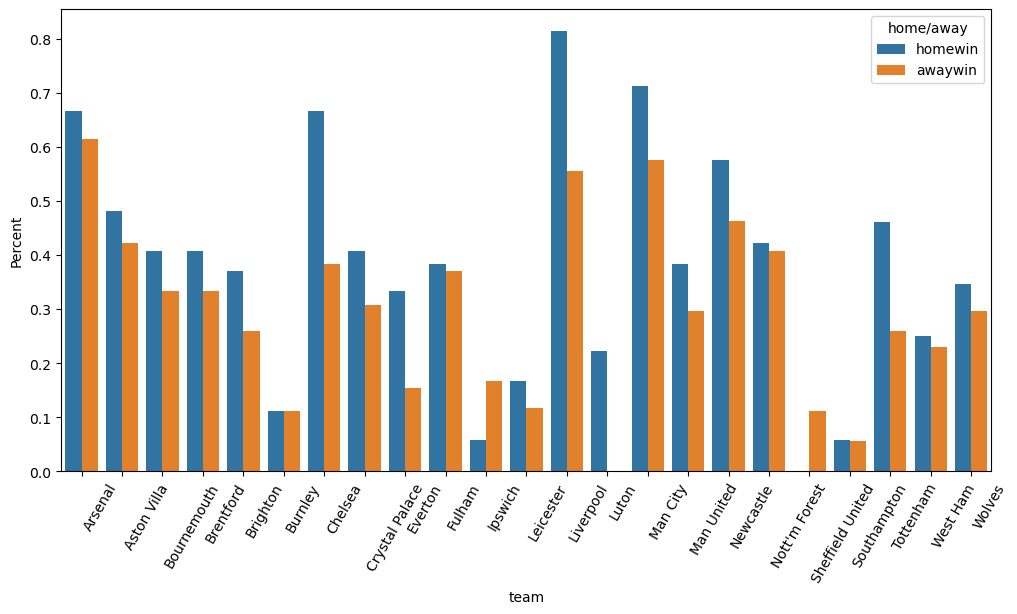

In [ ]:
wr_melt = winrate.melt(id_vars='team', var_name='home/away', value_name='Percent')
plt.figure(figsize=(12,6))
sns.barplot(wr_melt, x='team', y='Percent', hue='home/away')
plt.xticks(rotation = 60, ha='left')
plt.show()

5. Đội có số trận hòa nhiều nhất trong mùa
Mục đích: Xác định đội "an toàn" nhất (ít thắng, ít thua).

In [52]:
df['homedraw'] = df['FullTimeResult'].map({'H':0, 'D':1,'A':0})
df['awaydraw'] = df['FullTimeResult'].map({'H':0, 'D':1, 'A':0})

homedraw = df.groupby(['Season','HomeTeam'])['homedraw'].sum()
awaydraw = df.groupby(['Season','AwayTeam'])['awaydraw'].sum()

total_draw = homedraw.add(awaydraw, fill_value=0).reset_index()
total_draw.columns = ['season','team','totaldraw']

total_max = total_draw.groupby('season')['totaldraw'].max().reset_index()
total_max.columns = ['season', 'maxdraw']

result = pd.merge(total_draw, total_max, on='season', how='outer').reset_index()
print(result[result['totaldraw']== result['maxdraw']].sort_values('totaldraw',ascending=False).reset_index())

   level_0  index   season      team  totaldraw  maxdraw
0       27     27  2024/25   Everton         15       15
1        5      5  2023/24   Burnley          7        7
2        8      8  2023/24   Everton          7        7
3       18     18  2023/24  West Ham          7        7


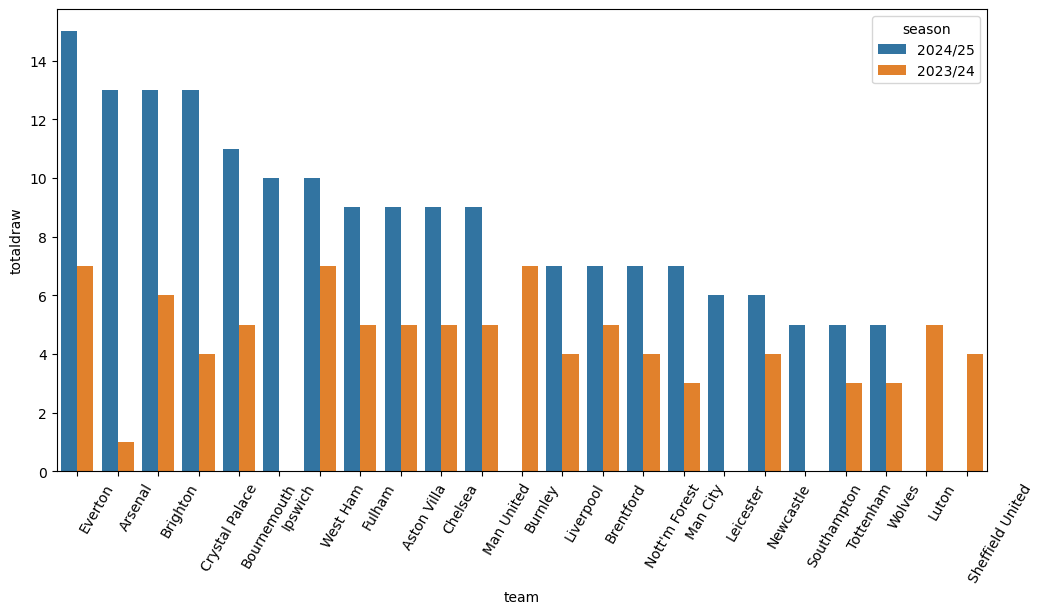

In [109]:
result1= total_draw.sort_values('totaldraw', ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(result1, x='team', y='totaldraw', hue='season')
plt.xticks(rotation=60, ha='left')
plt.show()